# Judge Robustness Figure

- **Top row**: Bar chart of total accuracy (both judges) + accuracy vs reasoning tokens (both judges overlaid)
- **Bottom rows**: 3 GPT-5-mini heatmaps (same size/ratios as Figure 2 in main_figures)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath, amssymb}"

cm = 1 / 2.54

# Color palette (same as Figure 2)
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging", ["#D55E00", "#F0F0F0", "#009E73"], N=256
)
num_colors = 256
palette_custom = [custom_cmap(i / (num_colors - 1)) for i in range(num_colors)]
color_min, color_max = 0, 100

from performance_eval import (parse_report, parse_domain, value_to_color, value_to_progress,
                              domain_performance, difficulty_performance, total_performance,
                              domain_per_difficulty_performance, domain_per_difficulty_tokens,
                              difficulty_tokens, total_tokens)

In [78]:
palette = sns.color_palette('colorblind')
palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [2]:
# ============================================================
# Data Loading
# ============================================================

def load_gpt5mini_judge(filepath):
    """Load correctness from GPT-5-mini batch API judge results."""
    results = []
    with open(filepath) as f:
        for line in f:
            entry = json.loads(line)
            body = entry['response']['body']
            correct = False
            for o in body['output']:
                if o['type'] == 'message':
                    parsed = json.loads(o['content'][0]['text'])
                    correct = parsed['correct'] == 'yes'
                    break
            results.append(correct)
    return results


# Load Omni-Judge data (from omni-judge_output files)
omni_oj = {}
for model, fname in [('o1', 'data/omni-judge_output_o1.jsonl'),
                      ('o3', 'data/omni-judge_output_o3.jsonl'),
                      ('o3_high', 'data/omni-judge_output_o3_high.jsonl')]:
    records = []
    with open(fname) as f:
        for line in f:
            entry = json.loads(line)
            info = parse_report(entry['omni-judge'])
            if info and 'Equivalence Judgement' in info:
                records.append({
                    'correct': info['Equivalence Judgement'] == 'TRUE',
                    'reasoning_tokens': entry['reasoning_tokens'],
                    'domain': entry['domain'],
                    'difficulty': entry['difficulty'],
                })
    omni_oj[model] = pd.DataFrame(records)

# Load GPT-5-mini judge data
omni_g5 = {}
for model in ['o1', 'o3', 'o3_high']:
    # Load responses for metadata
    responses = []
    with open(f'data/omni_math/reasoning_models/responses_{model}.jsonl') as f:
        for line in f:
            responses.append(json.loads(line))

    # Load GPT-5-mini judge correctness
    g5_correct = load_gpt5mini_judge(f'data/omni_math/reasoning_models/judge_results_{model}.jsonl')
    g5_records = []
    for i, entry in enumerate(responses):
        if i < len(g5_correct):
            g5_records.append({
                'correct': g5_correct[i],
                'reasoning_tokens': entry['reasoning_tokens'],
                'domain': entry['domain'],
                'difficulty': entry['difficulty'],
            })
    omni_g5[model] = pd.DataFrame(g5_records)

    oj_acc = omni_oj[model]['correct'].mean() * 100
    g5_acc = omni_g5[model]['correct'].mean() * 100
    print(f'{model}: Omni-Judge={oj_acc:.1f}%, GPT-5-mini={g5_acc:.1f}%')

o1: Omni-Judge=60.3%, GPT-5-mini=60.9%
o3: Omni-Judge=73.9%, GPT-5-mini=71.2%
o3_high: Omni-Judge=78.1%, GPT-5-mini=76.4%


In [3]:
# ============================================================
# Heatmap helpers
# ============================================================

TIERS = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
DOMAINS = ['Algebra', 'Applied Mathematics', 'Calculus', 'Discrete Mathematics', 'Geometry', 'Number Theory']
DOMAINS_SHORT = ['Algebra', 'Applied Math', 'Calculus', 'Discrete Math', 'Geometry', 'Number Theory']

x_names = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']
x_to_num = {t: i for i, t in enumerate(x_names)}
y_names = ['Number Theory', 'Geometry', 'Discrete Math', 'Calculus', 'Applied Math', 'Algebra']
y_to_num = {d: i for i, d in enumerate(y_names)}


def compute_heatmap_data(df, token_col='reasoning_tokens'):
    """Compute domain x tier accuracy and token usage from a DataFrame."""
    df_exp = df.explode('domain').copy()
    df_exp['domain'] = df_exp['domain'].apply(parse_domain)
    df_exp = df_exp.drop_duplicates()
    df_exp = df_exp.dropna(subset=['domain'])
    df_exp['domain'] = df_exp['domain'].apply(lambda x: 'Calculus' if x == 'Precalculus' else x)
    df_exp['tier'] = pd.qcut(df_exp['difficulty'], 4, labels=TIERS)

    rows = []
    for tier in TIERS:
        tier_df = df_exp[df_exp['tier'] == tier]
        for i, domain in enumerate(DOMAINS):
            dom_df = tier_df[tier_df['domain'] == domain]
            rows.append({
                'Domain': DOMAINS_SHORT[i], 'Tier': tier,
                'Accuracy': dom_df['correct'].mean() * 100 if len(dom_df) > 0 else 0,
                'Avg_Tokens': dom_df[token_col].mean() if len(dom_df) > 0 else 0,
            })
    dataframe = pd.DataFrame(rows)

    domain_df = pd.DataFrame([{
        'Domain': DOMAINS_SHORT[i],
        'Accuracy': df_exp[df_exp['domain'] == d]['correct'].mean() * 100 if len(df_exp[df_exp['domain'] == d]) > 0 else 0,
        'avg tokens': df_exp[df_exp['domain'] == d][token_col].mean() if len(df_exp[df_exp['domain'] == d]) > 0 else 0,
    } for i, d in enumerate(DOMAINS)])

    tier_df_out = pd.DataFrame([{
        'Tier': t,
        'Accuracy': df_exp[df_exp['tier'] == t]['correct'].mean() * 100,
        'avg tokens': df_exp[df_exp['tier'] == t][token_col].mean(),
    } for t in TIERS])

    return {
        'dataframe': dataframe,
        'domain_df': domain_df,
        'tier_df': tier_df_out,
        'total_acc': df['correct'].mean() * 100,
        'total_tokens': df[token_col].mean(),
    }


def compute_bin_accuracy(df, token_col='reasoning_tokens', n_bins=20, max_tokens=None):
    """Compute accuracy per token bin."""
    tokens = df[token_col].values
    correct = df['correct'].values
    if max_tokens is None:
        max_tokens = np.percentile(tokens, 99)
    bins = np.linspace(0, max_tokens, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    accs = []
    for i in range(len(bins) - 1):
        mask = (tokens >= bins[i]) & (tokens < bins[i+1])
        n = np.sum(mask)
        accs.append(np.mean(correct[mask]) * 100 if n > 10 else np.nan)
    return bin_centers, np.array(accs)


# Compute heatmap data for GPT-5-mini judge
hm_g5 = {m: compute_heatmap_data(omni_g5[m]) for m in ['o1', 'o3', 'o3_high']}

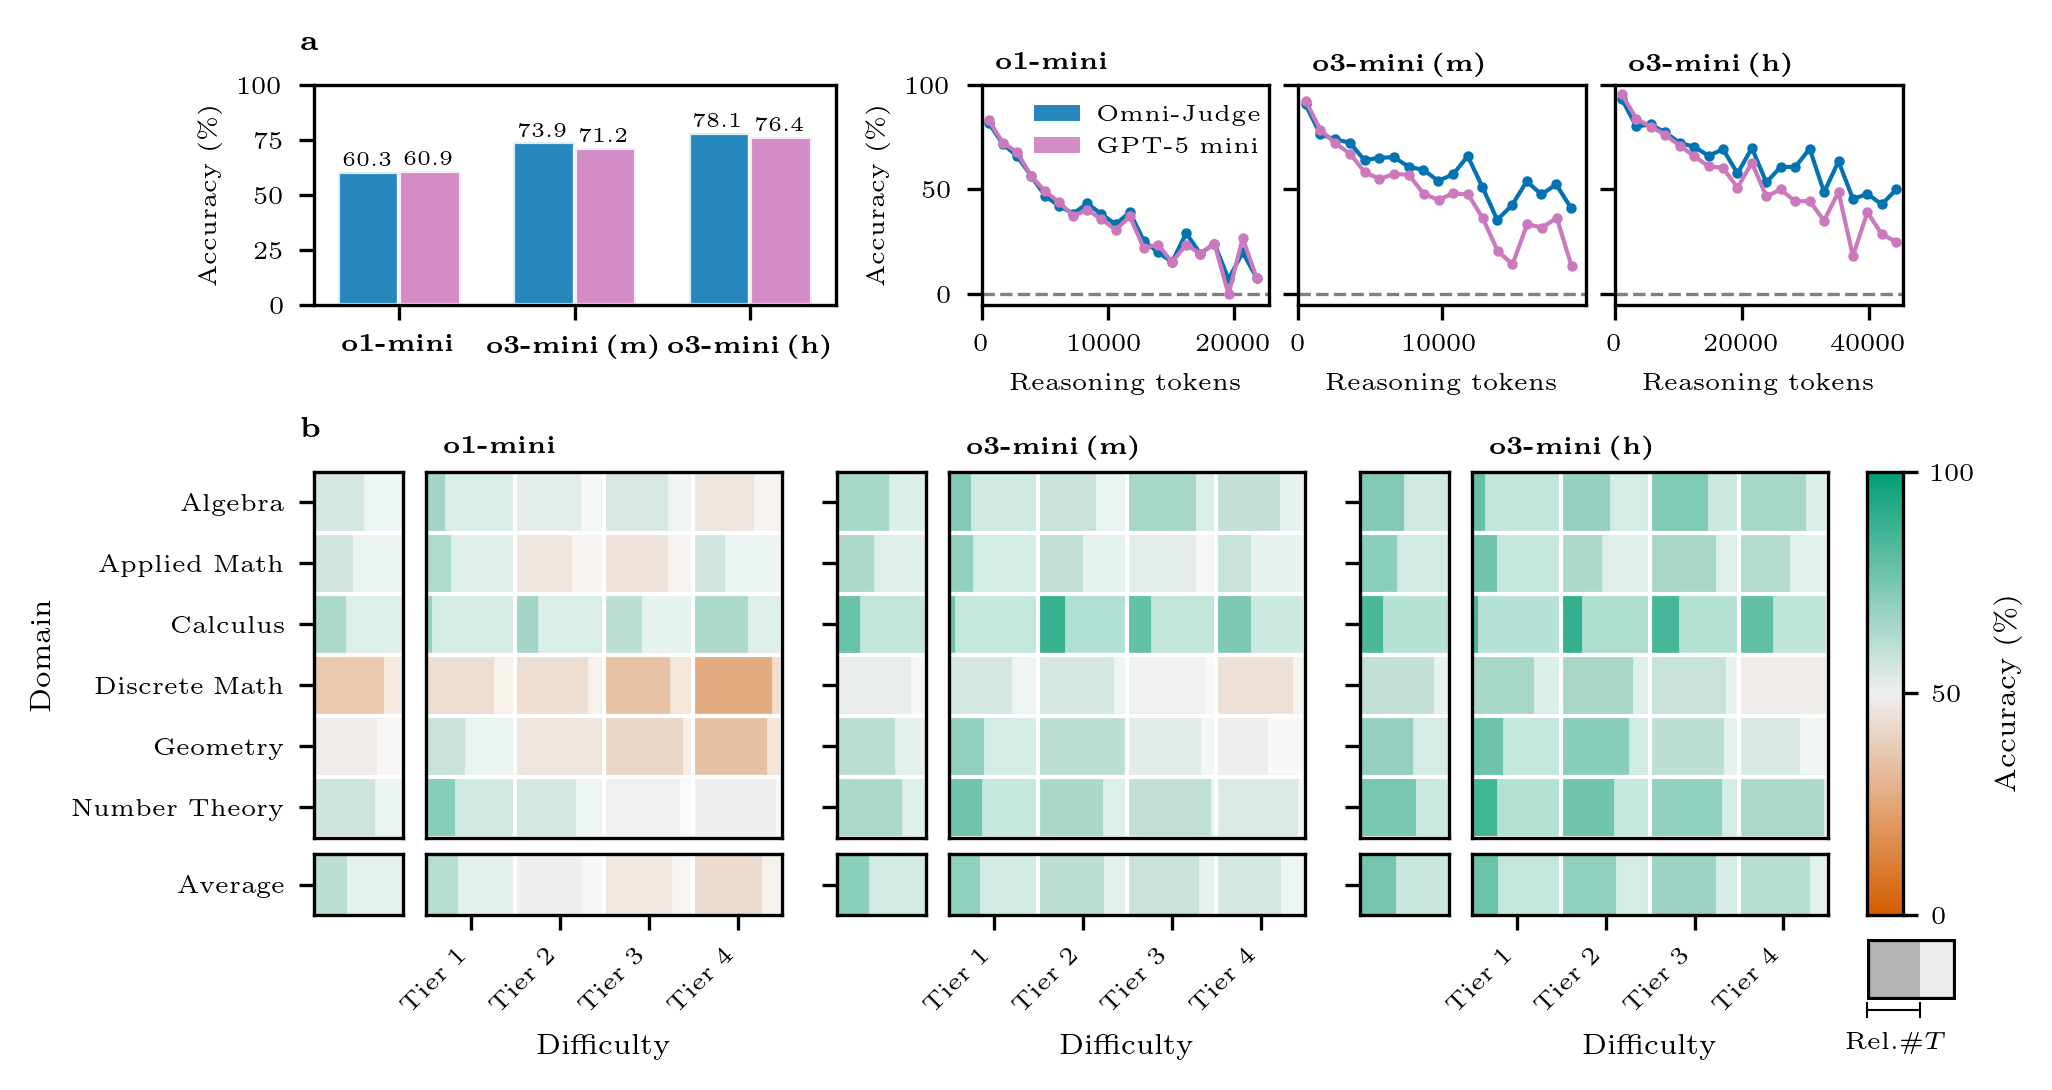

In [5]:
# ============================================================
# Judge Robustness Figure
# ============================================================
palette = sns.color_palette('colorblind')
# Judge colors
COLOR_OJ = palette[0]   # Omni-Judge (soft teal)
COLOR_G5 = palette[4]   # GPT-5-mini (soft coral)

# Figure dimensions
# main_figures heatmap section: figsize=(6.9, 9.2/4 + 0.5*cm)
fig_width = 6.9
bottom_height = 9.2/4 + 0.5*cm
top_row_height = 1
total_height = top_row_height + bottom_height

# Use subfigures so the bottom section has its own coordinate system
# This guarantees identical axis positions to main_figures
fig = plt.figure(figsize=(fig_width, total_height), dpi=300)
subfigs = fig.subfigures(2, 1, height_ratios=[top_row_height, bottom_height], hspace=0.1)

# -----------------------------------------------------------------
# TOP SUBFIGURE: bar chart + 3 accuracy vs tokens panels
# -----------------------------------------------------------------
# Create outer 1x2 grid: bar chart (left) | token panels (right)
outer_gs = subfigs[0].add_gridspec(1, 2, width_ratios=[1.75, 3], wspace=0.2)

# Bar chart in the left cell
ax_bar = subfigs[0].add_subplot(outer_gs[0, 0])

# 3 token panels in the right cell, with tighter spacing
inner_gs = outer_gs[0, 1].subgridspec(1, 3, wspace=0.1)
ax_T1 = subfigs[0].add_subplot(inner_gs[0])
ax_T2 = subfigs[0].add_subplot(inner_gs[1])
ax_T3 = subfigs[0].add_subplot(inner_gs[2])

# -----------------------------------------------------------------
# BOTTOM SUBFIGURE: exact same subplot_mosaic as main_figures
# -----------------------------------------------------------------
ax2 = subfigs[1].subplot_mosaic(
    [['B1', 'B2', 'C1', 'C2', 'D1', 'D2', 'C'],
     ['B3', 'B4', 'C3', 'C4', 'D3', 'D4', 'C'],
     ['legend', 'legend', 'legend', 'legend', 'legend', 'legend', 'legend']],
    gridspec_kw={'height_ratios': [1, 0.166, 0.12],
                 'width_ratios': [0.25, 1, 0.25, 1, 0.25, 1, 0.1],
                 'wspace': 0.2, 'hspace': 0.25},
)

# ---- Panel labels ----
ax_bar.text(-0.025, 1.25, r'\textbf{a}', ha='left', weight='bold',
            va='top', transform=ax_bar.transAxes, fontsize=7)
ax2['B1'].text(-0.15, 1.15, r'\textbf{b}', ha='left', weight='bold',
               va='top', transform=ax2['B1'].transAxes, fontsize=7)

# ====================
# TOP LEFT: Bar chart
# ====================
models = ['o1', 'o3', 'o3_high']
labels_m = ['o1-mini', 'o3-mini (m)', 'o3-mini (h)']

oj_accs = [omni_oj[m]['correct'].mean() * 100 for m in models]
g5_accs = [omni_g5[m]['correct'].mean() * 100 for m in models]

x_pos = np.arange(len(models))
width = 0.35

ax_bar.bar(x_pos - width/2, oj_accs, width, color=COLOR_OJ, alpha=0.85, edgecolor='white')
ax_bar.bar(x_pos + width/2, g5_accs, width, color=COLOR_G5, alpha=0.85, edgecolor='white')

for i in range(len(models)):
    ax_bar.text(x_pos[i] - width/2, oj_accs[i] + 0.8,
                f'{oj_accs[i]:.1f}', ha='center', va='bottom', fontsize=5)
    ax_bar.text(x_pos[i] + width/2, g5_accs[i] + 0.8,
                f'{g5_accs[i]:.1f}', ha='center', va='bottom', fontsize=5)

ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels([r'\textbf{o1-mini}', r'\textbf{o3-mini\,(m)}', r'\textbf{o3-mini\,(h)}'], fontsize=5)
ax_bar.set_ylabel(r'Accuracy (\%)', fontsize=6)
ax_bar.set_ylim(0, 100)
#ax_bar.spines['top'].set_visible(False)
#ax_bar.spines['right'].set_visible(False)
ax_bar.tick_params(axis='both', labelsize=6)


# ====================
# TOP RIGHT: Accuracy vs tokens
# ====================
top_panels = [(ax_T1, 'o1', 'o1-mini'), (ax_T2, 'o3', r'o3-mini\,(m)'), (ax_T3, 'o3_high', r'o3-mini\,(h)')]

for a, model, label in top_panels:
    centers, accs = compute_bin_accuracy(omni_oj[model])
    valid = ~np.isnan(accs)
    a.plot(centers[valid], accs[valid], '-', color=COLOR_OJ, linewidth=1, marker='o', markersize=1.5)

    centers, accs = compute_bin_accuracy(omni_g5[model])
    valid = ~np.isnan(accs)
    a.plot(centers[valid], accs[valid], '-', color=COLOR_G5, linewidth=1, marker='o', markersize=1.5)

   # a.set_title(rf'\textbf{{{label}}}', fontsize=6, pad=3)
    a.text(0.05, 1.15, rf'\textbf{{{label}}}', ha='left', weight='bold',
                 va='top', transform=a.transAxes, fontsize=6)
    #a.spines['top'].set_visible(False)
    #a.spines['right'].set_visible(False)
    a.tick_params(axis='both', labelsize=6)
    a.set_xlabel('Reasoning tokens', fontsize=6)
    a.set_xlim(0, np.max(centers[valid]) + 1000)
    a.set_ylim(-5, 100)
    a.plot([0,np.max(centers[valid])+1000], [0,0], '--', color='grey', linewidth=0.8, zorder=-1)

ax_T2.sharey(ax_T1)
ax_T3.sharey(ax_T1)
plt.setp(ax_T2.get_yticklabels(), visible=False)
plt.setp(ax_T3.get_yticklabels(), visible=False)
ax_T1.set_ylabel(r'Accuracy (\%)', fontsize=6)

legend_elements = [
    Patch(facecolor=COLOR_OJ, alpha=0.85, label='Omni-Judge'),
    Patch(facecolor=COLOR_G5, alpha=0.85, label='GPT-5 mini'),
]
ax_T1.legend(handles=legend_elements, fontsize=5.5, loc='upper right', bbox_to_anchor=(1.05, 1.0),
             facecolor='none', edgecolor='none')

# ====================
# BOTTOM: GPT-5-mini heatmaps (exact same code as main_figures)
# ====================

def plot_heatmap_panel(ax_main, ax_col, ax_row, ax_corner, data, model_name, show_y_labels=False):
    """Plot a single heatmap panel (same style as main_figures)."""
    df = data['dataframe']
    size = df['Avg_Tokens']
    margin = (max(size) - min(size)) * 0.05
    size_min, size_max = min(size) - margin, max(size) + margin

    ax_main.text(0.05, 1.1, rf'\textbf{{{model_name}}}', ha='left', weight='bold',
                 va='top', transform=ax_main.transAxes, fontsize=6)

    # Main heatmap
    for _, row in df.iterrows():
        x_p, y_p = x_to_num[row['Tier']], y_to_num[row['Domain']]
        progress = value_to_progress(row['Avg_Tokens'], size_min, size_max)
        color_fill = value_to_color(row['Accuracy'], palette_custom, color_min, color_max, num_colors)
        ax_main.add_patch(patches.Rectangle((x_p-0.5, y_p-0.5), 1, 1, color=color_fill, ec='white', alpha=0.4))
        ax_main.add_patch(patches.Rectangle((x_p-0.5, y_p-0.5), progress, 1, color=color_fill))

    for i in range(len(x_names) + 1): ax_main.axvline(i - 0.5, color='white', lw=1)
    for i in range(len(y_names) + 1): ax_main.axhline(i - 0.5, color='white', lw=1)
    ax_main.set(xticks=[], yticks=[], xlim=[-0.5, 3.5], ylim=[-0.5, 5.5])
    ax_main.grid(False)

    # Domain column (left)
    for _, row in data['domain_df'].iterrows():
        y_p = y_to_num[row['Domain']]
        progress = value_to_progress(row['avg tokens'], size_min, size_max)
        color_fill = value_to_color(row['Accuracy'], palette_custom, color_min, color_max, num_colors)
        ax_col.add_patch(patches.Rectangle((-0.5, y_p-0.5), 1, 1, color=color_fill, ec='white', alpha=0.4))
        ax_col.add_patch(patches.Rectangle((-0.5, y_p-0.5), progress, 1, color=color_fill))

    for i in range(len(y_names) + 1): ax_col.axhline(i - 0.5, color='white', lw=1)
    ax_col.set(xticks=[], xlim=[-0.5, 0.5], ylim=[-0.5, 5.5])
    ax_col.set_yticks([y_to_num[v] for v in y_names])
    ax_col.set_yticklabels(y_names if show_y_labels else [], fontsize=6)
    if show_y_labels: ax_col.set_ylabel('Domain', fontsize=7)
    ax_col.grid(False)

    # Tier row (bottom)
    for _, row in data['tier_df'].iterrows():
        x_p = x_to_num[row['Tier']]
        progress = value_to_progress(row['avg tokens'], size_min, size_max)
        color_fill = value_to_color(row['Accuracy'], palette_custom, color_min, color_max, num_colors)
        ax_row.add_patch(patches.Rectangle((x_p-0.5, -0.5), 1, 1, color=color_fill, ec='white', alpha=0.4))
        ax_row.add_patch(patches.Rectangle((x_p-0.5, -0.5), progress, 1, color=color_fill))

    for i in range(len(x_names) + 1): ax_row.axvline(i - 0.5, color='white', lw=1)
    ax_row.set(yticks=[], xlim=[-0.5, 3.5], ylim=[-0.5, 0.5])
    ax_row.set_xticks([x_to_num[v] for v in x_names])
    ax_row.set_xticklabels(x_names, rotation=45, ha='right', fontsize=6)
    ax_row.set_xlabel('Difficulty', fontsize=7)
    ax_row.grid(False)

    # Corner cell (total average)
    progress = value_to_progress(data['total_tokens'], size_min, size_max)
    color_fill = value_to_color(data['total_acc'], palette_custom, color_min, color_max, num_colors)
    ax_corner.add_patch(patches.Rectangle((-0.5, -0.5), 1, 1, color=color_fill, ec='white', alpha=0.4))
    ax_corner.add_patch(patches.Rectangle((-0.5, -0.5), progress, 1, color=color_fill))
    ax_corner.set(xticks=[], xlim=[-0.5, 0.5], ylim=[-0.5, 0.5])
    ax_corner.set_yticks([0])
    ax_corner.set_yticklabels(['Average'] if show_y_labels else [], fontsize=6)


# Plot all three models
plot_heatmap_panel(ax2['B2'], ax2['B1'], ax2['B4'], ax2['B3'], hm_g5['o1'], 'o1-mini', show_y_labels=True)
plot_heatmap_panel(ax2['C2'], ax2['C1'], ax2['C4'], ax2['C3'], hm_g5['o3'], r'o3-mini\,(m)')
plot_heatmap_panel(ax2['D2'], ax2['D1'], ax2['D4'], ax2['D3'], hm_g5['o3_high'], r'o3-mini\,(h)')

# Colorbar
gradient = np.linspace(color_min, color_max, num_colors).reshape(num_colors, 1)
ax2['C'].imshow(gradient, aspect='auto', cmap=ListedColormap(palette_custom))
ax2['C'].set_xticks([])
ax2['C'].set_yticks(np.linspace(0, num_colors - 1, 3))
ax2['C'].set_yticklabels([f'{v:.0f}' for v in np.linspace(color_min, color_max, 3)], fontsize=6)
ax2['C'].yaxis.tick_right()
ax2['C'].set_ylim(0, num_colors - 1)
x_bounds, y_bounds, w_bounds, h_bounds = ax2['C'].get_position().bounds
xb, yb, wb, hb = ax2['C'].get_position().bounds
ax2['C'].text(y_bounds+yb+3, num_colors / 2, r'Accuracy ($\%$)', rotation=90, ha='center', va='center', fontsize=7)


# ====================
# Adjust layout: exact same offsets as main_figures
# ====================
for key in ['B1', 'C1', 'D1']:
    pos = ax2[key].get_position()
    ax2[key].set_position([pos.x0 + 0.0075, pos.y0, pos.width, pos.height])

for key in ['B3', 'C3', 'D3']:
    pos = ax2[key].get_position()
    ax2[key].set_position([pos.x0 + 0.0075, pos.y0 + 0.032, pos.width, pos.height])

for key in ['B4', 'C4', 'D4']:
    pos = ax2[key].get_position()
    ax2[key].set_position([pos.x0, pos.y0 + 0.032, pos.width, pos.height])

pos_C = ax2['C'].get_position()
ax2['C'].set_position([pos_C.x0, pos_C.y0 + 0.032, pos_C.width, pos_C.height - 0.032])


# ====================
# Legend: grey progress bar (same as main_figures)
# ====================
pos_cbar = ax2['C'].get_position()
pos_B3 = ax2['B3'].get_position()
pos_legend = ax2['legend'].get_position()
legend_width = pos_B3.width
legend_height = pos_B3.height

legend_x = pos_cbar.x0
ax2['legend'].set_position([legend_x, pos_legend.y0 + 0.03, legend_width, legend_height])

ax2['legend'].set_xlim(-0.5, 0.5)
ax2['legend'].set_ylim(-0.5, 0.5)
ax2['legend'].axis('off')

progress_example = 0.6
ax2['legend'].add_patch(patches.Rectangle((-0.5, -0.5), 1, 1, facecolor='#A0A0A0', edgecolor=None, alpha=0.2, zorder=1))
ax2['legend'].add_patch(patches.Rectangle((-0.5, -0.5), progress_example, 1, facecolor='#606060', edgecolor=None, alpha=0.4, zorder=2))
ax2['legend'].add_patch(patches.Rectangle((-0.5, -0.5), 1, 1, facecolor='none', edgecolor='black', lw=1.5, zorder=10))

# Bracket annotation for Rel.#T
pos_leg = ax2['legend'].get_position()
bracket_y = pos_leg.y0 - 0.015
bracket_top = pos_leg.y0 - 0.005
bracket_bottom = bracket_y - 0.01
bracket_left = pos_leg.x0
bracket_right = pos_leg.x0 + (progress_example * pos_leg.width)
bracket_mid = (bracket_left + bracket_right) / 2

subfigs[1].add_artist(plt.Line2D([bracket_left, bracket_right], [bracket_y, bracket_y],
                                  color='black', lw=0.5, transform=subfigs[1].transSubfigure, clip_on=False))
subfigs[1].add_artist(plt.Line2D([bracket_left, bracket_left], [bracket_top, bracket_bottom],
                                  color='black', lw=0.5, transform=subfigs[1].transSubfigure, clip_on=False))
subfigs[1].add_artist(plt.Line2D([bracket_right, bracket_right], [bracket_top, bracket_bottom],
                                  color='black', lw=0.5, transform=subfigs[1].transSubfigure, clip_on=False))

subfigs[1].text(bracket_mid, bracket_bottom - 0.02, r"Rel.\#$T$", ha='center', va='top', fontsize=6)



# Align bar chart y-axis with bottom-left panel y-axis
b1_pos = ax2['B1'].get_position()
bar_pos = ax_bar.get_position()
ax_bar.set_position([b1_pos.x0, bar_pos.y0, bar_pos.x0 + bar_pos.width - b1_pos.x0, bar_pos.height])

plt.savefig('figures/FigureR1.pdf', dpi=300, bbox_inches='tight')
plt.show()